<a href="https://colab.research.google.com/github/Eason-none/sugar/blob/main/sugar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 第一次运行需要安装，之后不用
!pip install pandas numpy matplotlib scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from google.colab import files

print("✅ 所有工具包加载成功")

✅ 所有工具包加载成功


In [ ]:
!git clone https://github.com/IrinaStatsLab/Awesome-CGM.git

Cloning into 'Awesome-CGM'...
remote: Enumerating objects: 909, done.
remote: Counting objects: 100% (199/199), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 909 (delta 168), reused 113 (delta 113), pack-reused 710 (from 2)
Receiving objects: 100% (909/909), 278.17 KiB | 2.40 MiB/s, done.
Resolving deltas: 100% (466/466), done.


In [ ]:
!git clone https://github.com/IrinaStatsLab/GlucoBench.git

fatal: destination path 'GlucoBench' already exists and is not an empty directory.


In [ ]:
!pip install -r GlucoBench/requirements.txt

In [ ]:
# 第一步：看看下载到了什么
!find /content/GlucoBench -type f | head -40

/content/GlucoBench/README.md
/content/GlucoBench/paper_results/plots/figure4.pdf
/content/GlucoBench/paper_results/plots/figure3_annot.pptx
/content/GlucoBench/paper_results/plots/figure3.pdf
/content/GlucoBench/paper_results/plots/figure6.pdf
/content/GlucoBench/paper_results/plots/figure5.pdf
/content/GlucoBench/paper_results/plots/nhits_single_prediction.pdf
/content/GlucoBench/paper_results/plots/figure2.pdf
/content/GlucoBench/paper_results/plots/figure6.png
/content/GlucoBench/paper_results/figure5.ipynb
/content/GlucoBench/paper_results/tables.ipynb
/content/GlucoBench/paper_results/parser.py
/content/GlucoBench/paper_results/forecast_compute.ipynb
/content/GlucoBench/paper_results/forecast_plot.ipynb
/content/GlucoBench/paper_results/figure3.ipynb
/content/GlucoBench/paper_results/figure4.ipynb
/content/GlucoBench/paper_results/figure2.ipynb
/content/GlucoBench/paper_results/covariate_importance_xgb.ipynb
/content/GlucoBench/raw_data.zip
/content/GlucoBench/requirements.txt
/c

In [ ]:
# 第二步：看看 Awesome-CGM 里有什么
!find /content/Awesome-CGM -type f | head -40

/content/Awesome-CGM/README.md
/content/Awesome-CGM/ShinyGUI.Rproj
/content/Awesome-CGM/R/filter_missing_data.R
/content/Awesome-CGM/R/Lynch2022/Lynch2022_preprocessor.R
/content/Awesome-CGM/R/Dubosson2018/preprocessor.r
/content/Awesome-CGM/R/Marling2020/preprocessor.r
/content/Awesome-CGM/R/Broll2021/Broll2021_preprocessor.R
/content/Awesome-CGM/R/Brown2019/Brown2019_preprocessor.R
/content/Awesome-CGM/R/Tamborlane2008/preprocessor.r
/content/Awesome-CGM/R/Processing_Demo.md
/content/Awesome-CGM/R/Aleppo2017/preprocessor.R
/content/Awesome-CGM/R/Hall2018/preprocessor.r
/content/Awesome-CGM/R/Hall2018/Hall2018_preprocessor.R
/content/Awesome-CGM/R/Hall2018/meals_processor.R
/content/Awesome-CGM/R/plot_check_csv.R
/content/Awesome-CGM/R/Colas2019/preprocessor.r
/content/Awesome-CGM/R/Colas2019/Colas2019_preprocessor.R
/content/Awesome-CGM/R/Anderson2016/preprocessor.r
/content/Awesome-CGM/R/Shah2019/Shah2019_preprocessor.R
/content/Awesome-CGM/R/Tsalikian2005/preprocessor.r
/content/Aw

In [ ]:
# 解压数据
!unzip -q /content/GlucoBench/raw_data.zip -d /content/GlucoBench/
!find /content/GlucoBench/raw_data -type f | head -30

/content/GlucoBench/raw_data/weinstock.csv
/content/GlucoBench/raw_data/iglu.csv
/content/GlucoBench/raw_data/dubosson.csv
/content/GlucoBench/raw_data/colas.csv
/content/GlucoBench/raw_data/.DS_Store
/content/GlucoBench/raw_data/hall.csv


In [ ]:
import pandas as pd

# 先看 hall.csv（健康/糖尿病前期人群，最适合你）
hall = pd.read_csv('/content/GlucoBench/raw_data/hall.csv')
print("=== hall.csv ===")
print("行数、列数：", hall.shape)
print("列名：", hall.columns.tolist())
print(hall.head(5))

print("\n=== colas.csv ===")
colas = pd.read_csv('/content/GlucoBench/raw_data/colas.csv')
print("行数、列数：", colas.shape)
print("列名：", colas.columns.tolist())
print(colas.head(5))

=== hall.csv ===
行数、列数： (105426, 51)
列名： ['id', 'time', 'gl', 'Age', 'BMI', 'A1C', 'FBG', 'ogtt.2hr', 'insulin', 'hs.CRP', 'Tchol', 'Trg', 'HDL', 'LDL', 'mean_glucose', 'sd_glucose', 'range_glucose', 'min_glucose', 'max_glucose', 'quartile.25_glucose', 'median_glucose', 'quartile.75_glucose', 'mean_slope', 'max_slope', 'number_Random140', 'number_Random200', 'percent_below.80', 'percent_above.130', 'se_glucose_mean', 'numGE', 'mage', 'j_index', 'IQR', 'modd', 'distance_traveled', 'coef_variation', 'number_Random140_normByDays', 'number_Random200_normByDays', 'numGE_normByDays', 'distance_traveled_normByDays', 'diagnosis', 'freq_low', 'freq_moderate', 'freq_severe', 'glucotype', 'Height', 'Weight', 'Insulin_rate_dd', 'perc_cgm_prediabetic_range', 'perc_cgm_diabetic_range', 'SSPG']
            id                 time    gl   Age   BMI  A1C    FBG  ogtt.2hr  \
0  1636-69-001  2014-02-03 03:42:12  93.0  59.0  21.7  6.7  109.0     205.0   
1  1636-69-001  2014-02-03 03:47:12  93.0  59.0  21

In [ ]:
# 这一步是Claude写的数据清洗
import pandas as pd
import numpy as np

hall = pd.read_csv('/content/GlucoBench/raw_data/hall.csv')
colas = pd.read_csv('/content/GlucoBench/raw_data/colas.csv')

# 先看 hall 里有哪些 diagnosis 分类
print("=== Hall 人群分类 ===")
print(hall['diagnosis'].value_counts())
print(f"总人数：{hall['id'].nunique()} 人")

print("\n=== Colas T2DM分布 ===")
print(colas['T2DM'].value_counts())
print(f"总人数：{colas['id'].nunique()} 人")

# 只保留你需要的列，重命名统一
hall_clean = hall[['id','time','gl','Age','BMI','A1C','diagnosis']].copy()
hall_clean.columns = ['id','time','glucose','age','bmi','a1c','diagnosis']
hall_clean['time'] = pd.to_datetime(hall_clean['time'])
hall_clean['source'] = 'hall'

colas_clean = colas[['id','time','gl','age','BMI','HbA1c','T2DM']].copy()
colas_clean.columns = ['id','time','glucose','age','bmi','a1c','diagnosis']
colas_clean['time'] = pd.to_datetime(colas_clean['time'])
colas_clean['source'] = 'colas'

# 合并两个数据集
df = pd.concat([hall_clean, colas_clean], ignore_index=True)

# 删掉血糖明显异常的行（传感器故障）
df = df[(df['glucose'] >= 40) & (df['glucose'] <= 400)]

print(f"\n✅ 合并后总行数：{len(df)}")
print(f"✅ 总人数：{df['id'].nunique()} 人")
print(f"✅ 缺失值：\n{df.isnull().sum()}")

=== Hall 人群分类 ===
diagnosis
0    70536
1    25677
2     9213
Name: count, dtype: int64
总人数：57 人

=== Colas T2DM分布 ===
T2DM
False    104758
True       9495
Name: count, dtype: int64
总人数：208 人

✅ 合并后总行数：219670
✅ 总人数：265 人
✅ 缺失值：
id           0
time         0
glucose      0
age          0
bmi          0
a1c          0
diagnosis    0
source       0
dtype: int64


/tmp/ipykernel_1563/3243713847.py:34: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/3243713847.py:34: UserWarning: Glyph 34880 (\N{CJK UNIFIED IDEOGRAPH-8840}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/3243713847.py:34: UserWarning: Glyph 31958 (\N{CJK UNIFIED IDEOGRAPH-7CD6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/3243713847.py:34: UserWarning: Glyph 39184 (\N{CJK UNIFIED IDEOGRAPH-9910}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/3243713847.py:34: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/3243713847.py:34: UserWarning: Glyph 35686 (\N{CJK UNIFIED IDEOGRAPH-8B66}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/3243713847.py:34: UserWarning: Glyph 25106 (\N{CJK UNIFIED IDEOGRAPH-6212}) missing from current font.
  plt.tight_l

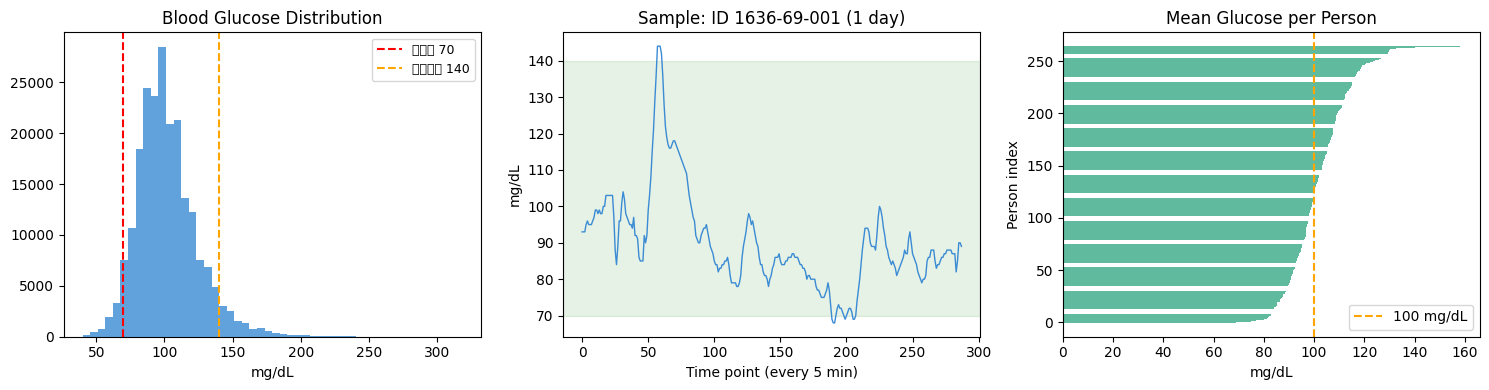

✅ 图表生成完成


In [ ]:
# 这一步是Claude写的可视化
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 图1：血糖分布
axes[0].hist(df['glucose'], bins=50, color='#3B8BD4', alpha=0.8, edgecolor='none')
axes[0].axvline(70,  color='red',    linestyle='--', label='低血糖 70')
axes[0].axvline(140, color='orange', linestyle='--', label='餐后警戒 140')
axes[0].set_title('Blood Glucose Distribution')
axes[0].set_xlabel('mg/dL')
axes[0].legend(fontsize=9)

# 图2：随机抽一个人的血糖曲线
sample_id = df['id'].unique()[0]
sample = df[df['id']==sample_id].sort_values('time').head(288)  # 1天
axes[1].plot(range(len(sample)), sample['glucose'], color='#3B8BD4', linewidth=1)
axes[1].axhspan(70, 140, alpha=0.1, color='green')
axes[1].set_title(f'Sample: ID {sample_id} (1 day)')
axes[1].set_ylabel('mg/dL')
axes[1].set_xlabel('Time point (every 5 min)')

# 图3：各人平均血糖
person_mean = df.groupby('id')['glucose'].mean().sort_values()
axes[2].barh(range(len(person_mean)), person_mean.values, color='#1D9E75', alpha=0.7)
axes[2].axvline(100, color='orange', linestyle='--', label='100 mg/dL')
axes[2].set_title('Mean Glucose per Person')
axes[2].set_xlabel('mg/dL')
axes[2].set_ylabel('Person index')
axes[2].legend()

plt.tight_layout()
plt.show()
print("✅ 图表生成完成")

In [ ]:
# 这一步是Claude写的特征工程
# 针对每个人，用过去60分钟预测30分钟后的血糖
LOOKBACK = 12   # 过去60分钟（12个×5分钟）
HORIZON  = 6    # 预测30分钟后

X, y, meta = [], [], []

for person_id, group in df.groupby('id'):
    group = group.sort_values('time').reset_index(drop=True)
    glucose = group['glucose'].values

    # 这个人数据太少就跳过
    if len(glucose) < LOOKBACK + HORIZON + 10:
        continue

    for i in range(LOOKBACK, len(glucose) - HORIZON):
        window = glucose[i-LOOKBACK : i]

        # 特征：12个历史值 + 趋势 + 变化率 + 均值 + 标准差
        trend  = window[-1] - window[0]          # 60分钟总趋势
        rate   = window[-1] - window[-3]          # 最近15分钟速率
        mean_g = window.mean()                    # 窗口内均值
        std_g  = window.std()                     # 窗口内波动

        features = list(window) + [trend, rate, mean_g, std_g]
        X.append(features)
        y.append(glucose[i + HORIZON])           # 30分钟后真实血糖
        meta.append(person_id)

X = np.array(X)
y = np.array(y)

print(f"✅ 特征矩阵：{X.shape}")
print(f"   {X.shape[0]} 个样本，{X.shape[1]} 个特征")
print(f"   来自 {len(set(meta))} 位受试者")
print(f"\n目标血糖分布：")
print(f"   均值：{y.mean():.1f} mg/dL")
print(f"   标准差：{y.std():.1f} mg/dL")
print(f"   范围：{y.min():.0f} ~ {y.max():.0f} mg/dL")

✅ 特征矩阵：(214900, 16)
   214900 个样本，16 个特征
   来自 265 位受试者

目标血糖分布：
   均值：102.1 mg/dL
   标准差：22.5 mg/dL
   范围：40 ~ 318 mg/dL


训练集：168006 样本（212 人）
测试集：46894 样本（53 人）

📏 MAE：9.1 mg/dL
   临床参考：<15 mg/dL 为良好，<10 mg/dL 为优秀


/tmp/ipykernel_1563/704454387.py:47: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/704454387.py:47: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/704454387.py:47: UserWarning: Glyph 34880 (\N{CJK UNIFIED IDEOGRAPH-8840}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/704454387.py:47: UserWarning: Glyph 31958 (\N{CJK UNIFIED IDEOGRAPH-7CD6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/704454387.py:47: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/704454387.py:47: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1563/704454387.py:47: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()

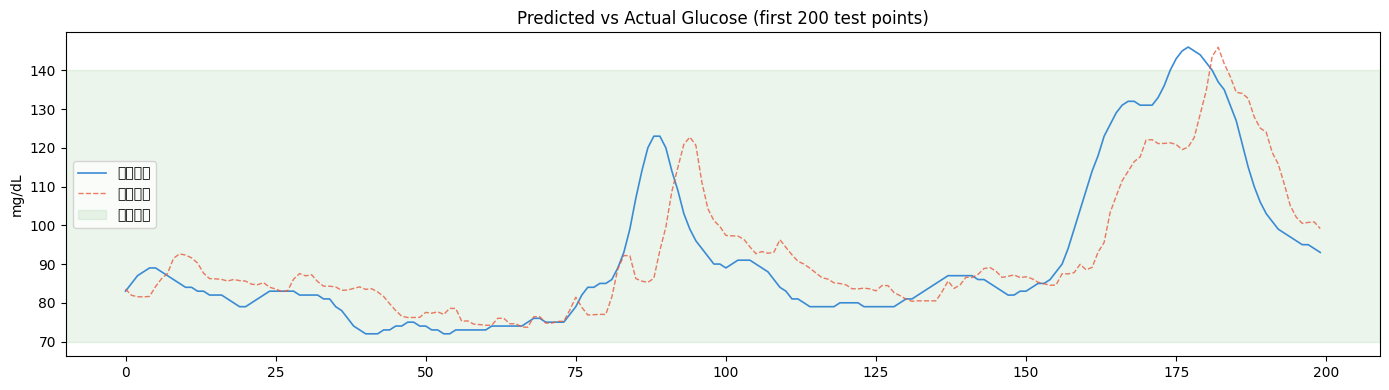

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# ⚠️ 关键：按人划分训练/测试集，不能随机打乱
all_ids = list(set(meta))
np.random.seed(42)
np.random.shuffle(all_ids)

split = int(len(all_ids) * 0.8)
train_ids = set(all_ids[:split])
test_ids  = set(all_ids[split:])

train_mask = np.array([m in train_ids for m in meta])
test_mask  = np.array([m in test_ids  for m in meta])

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"训练集：{len(y_train)} 样本（{len(train_ids)} 人）")
print(f"测试集：{len(y_test)} 样本（{len(test_ids)} 人）")

# 训练
model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
model.fit(X_train, y_train)

# 评估
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"\n📏 MAE：{mae:.1f} mg/dL")
print(f"   临床参考：<15 mg/dL 为良好，<10 mg/dL 为优秀")

# 可视化预测效果
plt.figure(figsize=(14, 4))
plt.plot(y_test[:200],  label='真实血糖', color='#3B8BD4', linewidth=1.2)
plt.plot(y_pred[:200], label='模型预测', color='#E8593C',
         linewidth=1, linestyle='--', alpha=0.8)
plt.axhspan(70, 140, alpha=0.08, color='green', label='正常范围')
plt.legend()
plt.title('Predicted vs Actual Glucose (first 200 test points)')
plt.ylabel('mg/dL')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(model, '/content/glucose_model.pkl')
print("✅ 模型已保存")

# 同时保存特征参数，API需要知道输入格式
import json
config = {
    'lookback': 12,
    'horizon': 6,
    'n_features': 16,
    'mae': 9.1
}
with open('/content/model_config.json', 'w') as f:
    json.dump(config, f)
print("✅ 配置已保存")

✅ 模型已保存
✅ 配置已保存


In [ ]:
import sklearn
print(sklearn.__version__)

1.4.2


In [ ]:
# 安装必要工具
!pip install fastapi uvicorn pyngrok -q

# 写 API 文件
api_code = '''
import joblib, json, numpy as np
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List

model = joblib.load("/content/glucose_model.pkl")

app = FastAPI(title="血糖预测 API")

class GlucoseInput(BaseModel):
    readings: List[float]

@app.get("/")
def root():
    return {"status": "运行中", "MAE": "9.1 mg/dL"}

@app.post("/predict")
def predict(data: GlucoseInput):
    if len(data.readings) != 12:
        return {"error": "需要12个血糖值"}
    window = np.array(data.readings)
    trend  = float(window[-1] - window[0])
    rate   = float(window[-1] - window[-3])
    mean_g = float(window.mean())
    std_g  = float(window.std())
    features = np.array([list(window) + [trend, rate, mean_g, std_g]])
    predicted = float(model.predict(features)[0])
    if predicted < 70:
        alert = "⚠️ 预测低血糖，建议补充糖分"
    elif predicted > 140:
        alert = "⚠️ 预测餐后偏高，建议适量运动"
    else:
        alert = "✅ 预测血糖正常"
    return {
        "预测30分钟后血糖": round(predicted, 1),
        "单位": "mg/dL",
        "风险提示": alert,
        "趋势": "上升" if trend > 3 else "下降" if trend < -3 else "平稳"
    }
'''

with open("/content/api.py", "w") as f:
    f.write(api_code)

print("✅ API 文件写好了")

✅ API 文件写好了


In [ ]:
import subprocess, time

# 启动 API 服务
proc = subprocess.Popen(
    ["uvicorn", "api:app", "--host", "0.0.0.0", "--port", "8000"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(3)

# 用 Colab 自带的方式生成公网链接（不需要注册）
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8000)")
print(f"✅ API 已启动！")
print(f"🔗 测试地址（复制到浏览器）：{url}")

✅ API 已启动！
🔗 测试地址（复制到浏览器）：https://8000-m-s-3vinfbww26qbr-b.us-west3-0.prod.colab.dev
